# Ev Fiyat Tahmin Modeli

## İş Problemi

Her bir eve ait özelliklerin ve ev fiyatlarının bulunduğu veriseti kullanılarak, farklı tipteki evlerin fiyatlarına ilişkin bir makine öğrenmesi projesi gerçekleştirilmek istenmektedir.


## Veri Seti Hikayesi

Ames, Iowa'daki konut evlerinden oluşan bu veri seti içerisinde **79 açıklayıcı değişken** bulunduruyor. Kaggle üzerinde bir yarışması da bulunan projenin veri seti ve yarışma sayfasına aşağıdaki linkten ulaşabilirsiniz. Veri seti bir Kaggle yarışmasına ait olduğundan dolayı **train** ve **test** olmak üzere iki farklı csv dosyası vardır. Test veri setinde ev fiyatları boş bırakılmış olup, bu değerleri sizin tahmin etmeniz beklenmektedir.

https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview/evaluation

| | |
|---|---|
| **1460** | Toplam Gözlem |
| **38** | Sayısal Değişken |
| **43** | Kategorik Değişken |


## Proje Görevleri

- **Görev 1:** Keşifçi Veri Analizi
- **Görev 2:** Feature Engineering
- **Görev 3:** Model Kurma


In [1]:
# Sayısal işlemler için NumPy kütüphanesini içe aktar
import numpy as np

# Tablo (DataFrame) işlemleri için Pandas kütüphanesini içe aktar
import pandas as pd

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Uyarı mesajlarını bastır (çıktıyı sadeleştirir; hataları saklamaz)
import warnings
warnings.filterwarnings("ignore")

# Kategorik değişkenleri sayısala çevirmek için LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Çapraz doğrulama ve hiperparametre araması için
from sklearn.model_selection import cross_val_score, GridSearchCV

# Regresyon hata metriği
from sklearn.metrics import mean_squared_error

# Görev 3'te karşılaştırılacak regresyon algoritmaları
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# --- Pandas görüntüleme ayarları ---
pd.set_option("display.max_columns", None)          # Tüm sütunlar gösterilsin
pd.set_option("display.max_rows", 100)              # Satır limiti
pd.set_option("display.width", 500)                 # Geniş çıktı
pd.set_option("display.float_format", lambda x: "%.3f" % x)  # Float formatı



# Görev 1: Keşifçi Veri Analizi

### Adım 1: Train ve Test veri setlerini okutup birleştiriniz. Birleştirdiğiniz veri üzerinden ilerleyiniz.


In [2]:
# Train veri setini oku (SalePrice hedef değişkeni DOLU)
train_df = pd.read_csv("datasets/house_prices/train.csv")

# Test veri setini oku (SalePrice hedef değişkeni BOŞ / yok)
test_df = pd.read_csv("datasets/house_prices/test.csv")

# Boyutları kontrol et: train ~ (1460, 81), test ~ (1459, 80)
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# Train ve Test'i alt alta birleştir.
# Amaç: eksik değer, rare, encoding işlemlerini tek seferde ve tutarlı uygulamak.
# ignore_index=True ile satır index'lerini 0'dan yeniden üret.
df = pd.concat([train_df, test_df], ignore_index=True)

# Birleşik boyut: ~ (2919, 81)
print("Birleşik shape:", df.shape)

# İlk 5 gözleme bak
df.head()


Train shape: (1460, 81)
Test shape : (1459, 80)
Birleşik shape: (2919, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706.000,Unf,0.000,150.000,856.000,GasA,Ex,Y,SBrkr,856,854,0,1710,1.000,0.000,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2.000,548.000,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.000
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.000,Unf,0.000,284.000,1262.000,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.000,1.000,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2.000,460.000,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.000
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.000,Unf,0.000,434.000,920.000,GasA,Ex,Y,SBrkr,920,866,0,1786,1.000,0.000,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2.000,608.000,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.000
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216.000,Unf,0.000,540.000,756.000,GasA,Gd,Y,SBrkr,961,756,0,1717,1.000,0.000,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3.000,642.000,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655.000,Unf,0.000,490.000,1145.000,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.000,0.000,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3.000,836.000,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.000


Train setinde **1460**, test setinde **1459** gözlem vardır. Birleştirme sonrası **2919 satır ve 81 sütun** ile ilerliyoruz. Test'te `SalePrice` kolonu olmadığı için birleşik veride bu hedef değişken NaN olarak gelir; bu satırlar daha sonra test olarak geri ayrılacaktır.


Veriye ilk bakış için standart keşif fonksiyonumuzu (`check_df`) kullanıyoruz. Shape, tip, head/tail, eksik değer ve betimsel istatistikleri tek çağrıda görürüz.


In [3]:
def check_df(dataframe, head=5):
    """
    Veri setinin genel resmini (shape, tip, ilk/son gözlemler, eksik değer, betimsel istatistik)
    tek bir fonksiyon çağrısıyla ekrana yazdırır. Herhangi bir yeni veri setine ilk bakışta
    kullanılacak standart bir "keşif" fonksiyonudur.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İncelenecek veri seti.
    head : int, opsiyonel
        head()/tail() ile gösterilecek satır sayısı (varsayılan: 5).
    """
    print("##################### Shape #####################")
    print(dataframe.shape)  # satır ve sütun sayısı

    print("##################### Types #####################")
    print(dataframe.dtypes)  # her değişkenin veri tipi

    print("##################### Head #####################")
    print(dataframe.head(head))  # ilk "head" satır

    print("##################### Tail #####################")
    print(dataframe.tail(head))  # son "head" satır (birleşik veride genelde test kısmı)

    print("##################### NA #####################")
    print(dataframe.isnull().sum())  # değişken başına eksik (NaN) değer sayısı

    print("##################### Quantiles #####################")
    # Sayısal sütunlar için çeyreklik / özet istatistikler
    print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)


# Birleşik veri setine uygula
check_df(df)


##################### Shape #####################
(2919, 81)
##################### Types #####################
Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
Street               str
Alley                str
LotShape             str
LandContour          str
Utilities            str
LotConfig            str
LandSlope            str
Neighborhood         str
Condition1           str
Condition2           str
BldgType             str
HouseStyle           str
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle            str
RoofMatl             str
Exterior1st          str
Exterior2nd          str
MasVnrType           str
MasVnrArea       float64
ExterQual            str
ExterCond            str
Foundation           str
BsmtQual             str
BsmtCond             str
BsmtExposure         str
BsmtFinType1         str
BsmtFinSF1       float64
BsmtFinType2  

Birleşik veri **2919 gözlem × 81 değişken**tir. `SalePrice` için train'de ortalama ≈ **180.921**, medyan ≈ **163.000**, min ≈ 34.9k, max ≈ 755k'tır. Ortalamanın medyandan büyük olması sağa çarpıklığa işaret eder. `MSSubClass`, `OverallQual`, `MoSold`, `YrSold` int tipinde görünmesine rağmen kategori anlamı taşır; tip düzeltmesi gerekir. `Alley`, `PoolQC`, `Fence`, `MiscFeature`, `FireplaceQu` gibi kolonlarda yüksek eksiklik beklenir.


### Adım 2: Numerik ve kategorik değişkenleri yakalayınız.


In [4]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Veri setindeki değişkenleri kategorik, numerik ve kardinal olarak ayırır.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        Analiz edilecek veri seti.
    cat_th : int
        Sayısal olup az sayıda benzersiz değere sahip sütunların kategorik kabul
        edilmesi için eşik (varsayılan: 10).
    car_th : int
        Kategorik olup çok fazla benzersiz değere sahip (kardinal) sütunlar için
        eşik (varsayılan: 20).

    Dönüş
    ------
    cat_cols : list
        Kategorik sütun isimleri.
    num_cols : list
        Numerik sütun isimleri.
    cat_but_car : list
        Kategorik görünüp çok fazla benzersiz değer içeren sütun isimleri.
    """
    def is_cat_dtype(series):
        # object veya string dtype kategorik adayıdır
        # (yeni pandas sürümlerinde astype(str) sonrası tip "str" olabilir)
        return pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series)

    # 1) Yazısal (object/string) kolonlar
    cat_cols = [col for col in dataframe.columns if is_cat_dtype(dataframe[col])]

    # 2) Numerik görünümlü ama az sınıfı olanlar (num_but_cat)
    num_but_cat = [col for col in dataframe.columns
                   if dataframe[col].nunique() < cat_th and not is_cat_dtype(dataframe[col])]

    # 3) Yazısal ama çok sınıflı olanlar (cat_but_car)
    cat_but_car = [col for col in dataframe.columns
                   if dataframe[col].nunique() > car_th and is_cat_dtype(dataframe[col])]

    # Kategorik listeye num_but_cat ekle, cat_but_car çıkar
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # Numerik kolonlar
    num_cols = [col for col in dataframe.columns if not is_cat_dtype(dataframe[col])]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # Özet yazdır
    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car


# Değişken tiplerini yakala
cat_cols, num_cols, cat_but_car = grab_col_names(df)


Observations: 2919
Variables: 81
cat_cols: 52
num_cols: 28
cat_but_car: 1
num_but_cat: 10


İlk yakalamada **52 kategorik**, **28 numerik** ve **1 kardinal** (`Neighborhood`) değişken bulunmuştur. Ayrıca 10 adet `num_but_cat` vardır. `MSSubClass`, `OverallQual`, `MoSold`, `YrSold` gibi kolonlar henüz numerik listede görünebilir; bir sonraki adımda tip düzeltmesi yapılacaktır. `Neighborhood` fiyatı güçlü etkilediği için kardinal diye dışarıda bırakılmamalıdır.


In [5]:
# Yakalanan listeleri incele
print("Kategorik değişkenler:\n", cat_cols)
print("\nNumerik değişkenler:\n", num_cols)
print("\nKardinal değişkenler:\n", cat_but_car)


Kategorik değişkenler:
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition', 'OverallCond', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'Fireplaces', 'GarageCars', 'YrSold']

Numerik değişkenler:
 ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'TotRmsAbvGrd', 'GarageYrBlt', 'Ga

### Adım 3: Gerekli düzenlemeleri yapınız. (Tip hatası olan değişkenler gibi)


In [6]:
# Tip hatası olan değişkenler:
# MSSubClass, OverallQual, OverallCond, MoSold, YrSold sayısal kodlanmış olsa da
# kategori anlamı taşır. Bunları object tipine çeviriyoruz.

type_fix_cols = ["MSSubClass", "OverallQual", "OverallCond", "MoSold", "YrSold"]

for col in type_fix_cols:
    df[col] = df[col].astype("object")
    print(f"{col} tipi object olarak güncellendi. nunique={df[col].nunique()}")


MSSubClass tipi object olarak güncellendi. nunique=16
OverallQual tipi object olarak güncellendi. nunique=10
OverallCond tipi object olarak güncellendi. nunique=9
MoSold tipi object olarak güncellendi. nunique=12
YrSold tipi object olarak güncellendi. nunique=5


In [7]:
# Tip düzeltmesinden sonra listeleri yeniden yakala.
# Neighborhood (~25 sınıf) ev fiyatında kritik olduğu için car_th=30 ile kategorik tutuyoruz.
cat_cols, num_cols, cat_but_car = grab_col_names(df, car_th=30)

# Id modelde kullanılmaz; SalePrice hedeftir -> numerik özellik listesinden çıkar
num_cols = [col for col in num_cols if col not in ["Id", "SalePrice"]]

print("Güncel cat_cols:", len(cat_cols))
print("Güncel num_cols:", len(num_cols))
print("cat_but_car:", cat_but_car)


Observations: 2919
Variables: 81
cat_cols: 56
num_cols: 25
cat_but_car: 0
num_but_cat: 8
Güncel cat_cols: 56
Güncel num_cols: 23
cat_but_car: []


Tip düzeltmesi sonrası kategorik değişken sayısı 56'ya çıkmış, kardinal liste boşalmıştır (`Neighborhood` artık kategorik). Modellemede kullanılacak numerik özellik sayısı 23'tür (`Id` ve `SalePrice` hariç).


### Adım 4: Numerik ve kategorik değişkenlerin veri içindeki dağılımını gözlemleyiniz.


In [8]:
def cat_summary(dataframe, col_name, plot=False):
    """
    Belirtilen kategorik sütunun frekans (adet) ve oran (yüzde) dağılımını gösterir.
    plot=True verilirse countplot çizer.
    """
    print(pd.DataFrame({
        col_name: dataframe[col_name].value_counts(),
        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)
    }))
    print("##########################################")

    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.xticks(rotation=45)
        plt.show(block=True)


def num_summary(dataframe, numerical_col, plot=False):
    """
    Belirtilen sayısal değişkenin betimsel istatistiklerini ve yüzdeliklerini gösterir.
    plot=True verilirse histogram çizer.
    """
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)


In [9]:
# Tüm kategorik değişkenlerin dağılımını incele
# Not: Kolon sayısı fazla olduğu için plot=False; istenirse plot=True yapılabilir
for col in cat_cols:
    cat_summary(df, col, plot=False)


            MSSubClass  Ratio
MSSubClass                   
20                1079 36.965
60                 575 19.699
50                 287  9.832
120                182  6.235
30                 139  4.762
70                 128  4.385
160                128  4.385
80                 118  4.042
90                 109  3.734
190                 61  2.090
85                  48  1.644
75                  23  0.788
45                  18  0.617
180                 17  0.582
40                   6  0.206
150                  1  0.034
##########################################
          MSZoning  Ratio
MSZoning                 
RL            2265 77.595
RM             460 15.759
FV             139  4.762
RH              26  0.891
C (all)         25  0.856
##########################################
        Street  Ratio
Street               
Pave      2907 99.589
Grvl        12  0.411
##########################################
       Alley  Ratio
Alley              
Grvl     120  4.111
P

In [10]:
# Tüm numerik değişkenlerin dağılımını incele
for col in num_cols:
    num_summary(df, col, plot=False)


count   2433.000
mean      69.306
std       23.345
min       21.000
5%        32.000
10%       43.000
20%       53.000
30%       60.000
40%       63.000
50%       68.000
60%       73.000
70%       78.000
80%       84.000
90%       95.000
95%      107.000
99%      135.680
max      313.000
Name: LotFrontage, dtype: float64
count     2919.000
mean     10168.114
std       7886.996
min       1300.000
5%        3182.000
10%       4922.400
20%       7007.600
30%       7960.400
40%       8741.000
50%       9453.000
60%      10151.600
70%      11001.200
80%      12203.800
90%      14300.600
95%      17142.900
99%      33038.640
max     215245.000
Name: LotArea, dtype: float64
count   2919.000
mean    1971.313
std       30.291
min     1872.000
5%      1915.000
10%     1924.000
20%     1947.000
30%     1957.000
40%     1965.000
50%     1973.000
60%     1984.000
70%     1998.000
80%     2003.000
90%     2006.000
95%     2007.000
99%     2008.000
max     2010.000
Name: YearBuilt, dtype: float64
cou

SalePrice skewness (ham)   : 1.883
SalePrice skewness (log1p) : 0.121


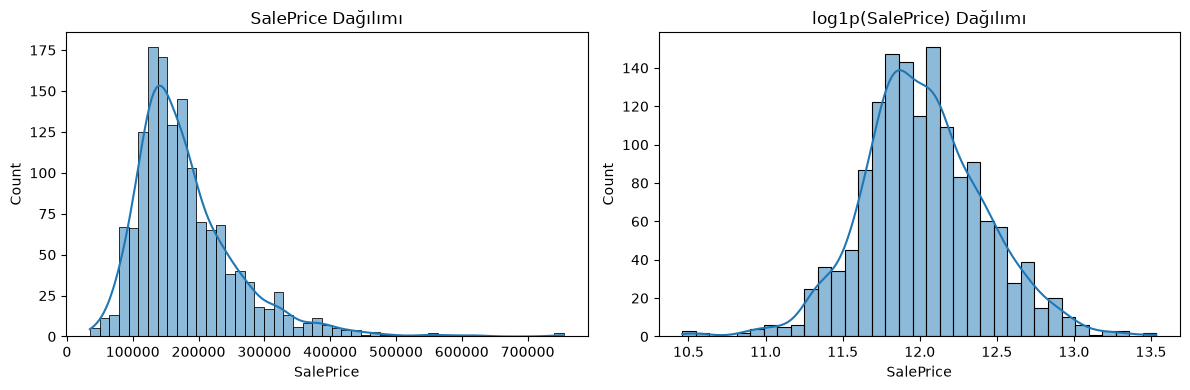

In [11]:
# Hedef değişken (SalePrice) dağılımı — yalnızca train satırlarında doludur
# Sağa çarpıklık varsa ileride log dönüşümü (bonus) değerlendirilir
target_series = df.loc[df["SalePrice"].notnull(), "SalePrice"]

print("SalePrice skewness (ham)   :", round(target_series.skew(), 3))
print("SalePrice skewness (log1p) :", round(np.log1p(target_series).skew(), 3))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(target_series, kde=True)
plt.title("SalePrice Dağılımı")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(target_series), kde=True)
plt.title("log1p(SalePrice) Dağılımı")
plt.tight_layout()
plt.show()


Ham `SalePrice` çarpıklığı **1.883** (sağa çarpık) iken `log1p` sonrası **0.121**'e düşmüştür. Yani log dönüşümü dağılımı belirgin şekilde simetrikleştirir. Kaggle metriği de log-RMSE kullandığı için bonus adımda log dönüşümü kullanmak doğru tercihtir.


### Adım 5: Kategorik değişkenler ile hedef değişken incelemesini yapınız.


In [12]:
def target_summary_with_cat(dataframe, target, categorical_col):
    """
    Kategorik değişkenin her bir sınıfı için hedef değişken ortalamasını hesaplar.
    Örn. Neighborhood sınıflarına göre ortalama SalePrice.
    """
    print(pd.DataFrame({
        "TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()
    }).sort_values("TARGET_MEAN", ascending=False), end="\n\n\n")


# Hedef yalnızca train'de dolu olduğu için analizi train satırlarında yap
train_only = df[df["SalePrice"].notnull()].copy()

for col in cat_cols:
    target_summary_with_cat(train_only, "SalePrice", col)


            TARGET_MEAN
MSSubClass             
60           239948.502
120          200779.080
75           192437.500
20           185224.812
80           169736.552
70           166772.417
40           156125.000
85           147810.000
50           143302.972
160          138647.381
90           133541.077
190          129613.333
45           108591.667
180          102300.000
30            95829.725


          TARGET_MEAN
MSZoning             
FV         214014.062
RL         191004.995
RH         131558.375
RM         126316.830
C (all)     74528.000


        TARGET_MEAN
Street             
Pave     181130.539
Grvl     130190.500


       TARGET_MEAN
Alley             
Pave    168000.585
Grvl    122219.080


          TARGET_MEAN
LotShape             
IR2        239833.366
IR3        216036.500
IR1        206101.665
Reg        164754.818


             TARGET_MEAN
LandContour             
HLS           231533.940
Low           203661.111
Lvl           180183.747
Bnk           1

 Kategorik × hedef incelemesinde güçlü sinyaller vardır:
- **Neighborhood:** `NoRidge` (~335k), `NridgHt` (~316k), `StoneBr` (~310k) en pahalı; `MeadowV` (~99k), `IDOTRR` (~100k) daha ucuz mahallelerdir. Lokasyon etkisi nettir.
- **OverallQual:** Kalite 1 → ~50k, kalite 10 → ~439k. Kalite arttıkça fiyat monoton artar; bu, en güçlü ilişkilerden biridir.
- Kalite/ kondisyon tipi değişkenler (`ExterQual`, `KitchenQual`, `BsmtQual` vb.) için de benzer sıralı ilişki beklenir.


### Adım 6: Aykırı gözlem var mı inceleyiniz.


In [13]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    """
    IQR yöntemiyle aykırı değer alt/üst sınırlarını hesaplar.

    Parametreler
    ----------
    dataframe : pd.DataFrame
    col_name : str
    q1, q3 : float
        Alt/üst çeyreklik. Ev fiyatı verisinde 0.05/0.95 daha toleranslıdır.
    """
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    low_limit = quartile1 - 1.5 * interquantile_range
    up_limit = quartile3 + 1.5 * interquantile_range
    return low_limit, up_limit


def check_outlier(dataframe, col_name):
    """
    Verilen değişkende IQR sınırları dışında en az bir aykırı gözlem olup olmadığını
    True/False olarak döner.
    """
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    return dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None)


# Numerik değişkenlerde aykırı gözlem kontrolü
for col in num_cols:
    print(col, check_outlier(df, col))


LotFrontage True
LotArea True
YearBuilt False
YearRemodAdd False
MasVnrArea True
BsmtFinSF1 True
BsmtFinSF2 True
BsmtUnfSF False
TotalBsmtSF True
1stFlrSF True
2ndFlrSF False
LowQualFinSF True
GrLivArea True
TotRmsAbvGrd False
GarageYrBlt True
GarageArea False
WoodDeckSF True
OpenPorchSF True
EnclosedPorch True
3SsnPorch True
ScreenPorch True
PoolArea True
MiscVal True


`q1=0.05`, `q3=0.95` IQR eşiğiyle birçok alan değişkeninde (`LotArea`, `GrLivArea`, `TotalBsmtSF`, `PoolArea` vb.) aykırı değer tespit edilmiştir. `YearBuilt` ve `YearRemodAdd` için aykırı gözlem yoktur. Ev verisinde uç değerler (çok büyük arsa, özel havuz) gerçek olabileceğinden silmek yerine baskılamak tercih edilecektir.


### Adım 7: Eksik gözlem var mı inceleyiniz.


In [14]:
def missing_values_table(dataframe, na_name=False):
    """
    Veri setindeki eksik (NaN) değerleri analiz eder ve özet tablo halinde gösterir.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İncelenecek veri seti.
    na_name : bool, opsiyonel
        True verilirse eksik değere sahip kolon isimlerinin listesini döndürür.
    """
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)

    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=["n_miss", "ratio"])
    print(missing_df, end="\n")

    if na_name:
        return na_columns


# Eksik değer tablosunu incele
# Not: PoolQC, Alley, Fence vb. yüksek NaN oranları çoğu zaman "özellik yok" anlamına gelir.
# SalePrice NaN'ları ise test setinin işaretidir; doldurulmaz.
na_cols = missing_values_table(df, na_name=True)


              n_miss  ratio
PoolQC          2909 99.660
MiscFeature     2814 96.400
Alley           2721 93.220
Fence           2348 80.440
MasVnrType      1766 60.500
SalePrice       1459 49.980
FireplaceQu     1420 48.650
LotFrontage      486 16.650
GarageCond       159  5.450
GarageYrBlt      159  5.450
GarageFinish     159  5.450
GarageQual       159  5.450
GarageType       157  5.380
BsmtExposure      82  2.810
BsmtCond          82  2.810
BsmtQual          81  2.770
BsmtFinType2      80  2.740
BsmtFinType1      79  2.710
MasVnrArea        23  0.790
MSZoning           4  0.140
Functional         2  0.070
BsmtHalfBath       2  0.070
BsmtFullBath       2  0.070
Utilities          2  0.070
KitchenQual        1  0.030
TotalBsmtSF        1  0.030
BsmtUnfSF          1  0.030
GarageCars         1  0.030
GarageArea         1  0.030
BsmtFinSF2         1  0.030
BsmtFinSF1         1  0.030
Exterior2nd        1  0.030
Exterior1st        1  0.030
SaleType           1  0.030
Electrical         1

**Yorum:** Eksik oranları incelendiğinde `PoolQC` (~%99.7), `MiscFeature` (~%96.4), `Alley` (~%93.2), `Fence` (~%80.4) gibi değişkenlerde boşluklar çok yüksektir; bunlar çoğunlukla “özellik yok” anlamına gelir ve `"None"` ile doldurulmalıdır. `SalePrice` eksikleri (~%50) test setidir, doldurulmaz. `LotFrontage` (~%16.7) için mahalle medyanı mantıklıdır. Garage/Bsmt grubundaki ~%2–5 eksikler de yapısal yoklukla ilişkilidir.


# Görev 2: Feature Engineering

### Adım 1: Eksik ve aykırı gözlemler için gerekli işlemleri yapınız.


#### Aykırı değerleri baskılama

Aykırı gözlemleri silmek yerine eşik değerlere çekiyoruz (winsorization). Böylece gözlem sayısı korunur.


In [15]:
def replace_with_thresholds(dataframe, variable):
    """
    Belirtilen değişkenin aykırı değerlerini alt ve üst eşiklerle değiştirir (baskılar).
    """
    low_limit, up_limit = outlier_thresholds(dataframe, variable)

    # Integer kolonlara float eşik yazabilmek için tipi yükselt
    if pd.api.types.is_integer_dtype(dataframe[variable]):
        dataframe[variable] = dataframe[variable].astype(float)

    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
    return dataframe


# Tüm numerik değişkenlerde aykırı değer baskılama
for col in num_cols:
    replace_with_thresholds(df, col)

# Baskılama sonrası kontrol (hepsinin False olması beklenir)
for col in num_cols:
    print(col, check_outlier(df, col))


LotFrontage False
LotArea False
YearBuilt False
YearRemodAdd False
MasVnrArea False
BsmtFinSF1 False
BsmtFinSF2 False
BsmtUnfSF False
TotalBsmtSF False
1stFlrSF False
2ndFlrSF False
LowQualFinSF False
GrLivArea False
TotRmsAbvGrd False
GarageYrBlt False
GarageArea False
WoodDeckSF False
OpenPorchSF False
EnclosedPorch False
3SsnPorch False
ScreenPorch False
PoolArea False
MiscVal False


Baskılama sonrası tüm numerik değişkenlerde `check_outlier` sonucu **False** dönmüştür. Yani uç değerler eşiklere çekilmiş, gözlem sayısı korunmuştur.


#### Eksik değerleri doldurma

- Yapısal yokluk anlamındaki kategorikler → `"None"`
- Yapısal yokluk anlamındaki sayısallar → `0`
- `LotFrontage` → mahalle (`Neighborhood`) medyanı
- Kalan az eksikler → kategori: mod, sayısal: medyan
- `SalePrice` eksikleri doldurulmaz (test seti)


In [16]:
# "Yokluk" anlamındaki kategorik eksikleri "None" ile doldur
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")

# "Yokluk" anlamındaki sayısal eksikleri 0 ile doldur
zero_cols = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath",
    "MasVnrArea"
]

for col in zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# LotFrontage: aynı mahalledeki medyan ile doldur
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)
# Hâlâ NaN varsa genel medyan
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

# SalePrice hariç kalan eksikler
remaining_na_cols = [col for col in df.columns if df[col].isnull().sum() > 0 and col != "SalePrice"]

for col in remaining_na_cols:
    if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mode()[0])  # en sık sınıf
    else:
        df[col] = df[col].fillna(df[col].median())   # medyan

# Kontrol: SalePrice dışında eksik kalmamalı
print("SalePrice hariç eksik sütun sayısı:",
      df.drop(columns=["SalePrice"]).isnull().any().sum())
missing_values_table(df)


SalePrice hariç eksik sütun sayısı: 0
           n_miss  ratio
SalePrice    1459 49.980


SalePrice hariç eksik sütun sayısı **0**'a inmiştir. Kalan tek eksik blok `SalePrice` (1459 NaN, ~%50) olup bunlar test satırlarıdır; doğru şekilde doldurulmamış / silinmemiştir.


### Adım 2: Rare Encoder uygulayınız.


In [17]:
def rare_analyser(dataframe, target, cat_cols):
    """
    Kategorik değişkenlerdeki her bir sınıfın; adedini (COUNT), toplam içindeki oranını (RATIO)
    ve hedef değişkene göre ortalamasını (TARGET_MEAN) gösterir. Bu analiz, çok az örneği olan
    ("nadir"/rare) sınıfları tespit etmemize yardımcı olur.
    """
    for col in cat_cols:
        print(col, ":", len(dataframe[col].value_counts()))
        print(pd.DataFrame({
            "COUNT": dataframe[col].value_counts(),
            "RATIO": dataframe[col].value_counts() / len(dataframe),
            "TARGET_MEAN": dataframe.groupby(col)[target].mean()
        }), end="\n\n\n")


def rare_encoder(dataframe, rare_perc, exclude_cols=None):
    """
    Toplam içindeki oranı rare_perc değerinin altında kalan (nadir görülen) kategorileri
    "Rare" ortak etiketiyle birleştirir. Böylece çok az örneği olan sınıfların modelde
    gürültüye (overfitting'e) sebep olması engellenir.

    Parametreler
    ----------
    dataframe : pd.DataFrame
    rare_perc : float
        Nadirlik eşiği (örn. 0.01 -> %1).
    exclude_cols : list, opsiyonel
        Rare birleştirmeye dahil edilmeyecek kolonlar.
        OverallQual gibi ordinal kolonlar buraya yazılmalıdır.
    """
    temp_df = dataframe.copy()
    exclude_cols = exclude_cols or []

    rare_columns = [
        col for col in temp_df.columns
        if col not in exclude_cols
        and (pd.api.types.is_object_dtype(temp_df[col]) or pd.api.types.is_string_dtype(temp_df[col]))
        and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)
    ]

    for var in rare_columns:
        tmp = temp_df[var].value_counts() / len(temp_df)
        rare_labels = tmp[tmp < rare_perc].index
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), "Rare", temp_df[var])

    return temp_df


# Rare analizi (hedef ortalaması yalnızca train'de anlamlı)
rare_analyser(df[df["SalePrice"].notnull()], "SalePrice", cat_cols)


MSSubClass : 15
            COUNT  RATIO  TARGET_MEAN
MSSubClass                           
20            536  0.367   185224.812
30             69  0.047    95829.725
40              4  0.003   156125.000
45             12  0.008   108591.667
50            144  0.099   143302.972
60            299  0.205   239948.502
70             60  0.041   166772.417
75             16  0.011   192437.500
80             58  0.040   169736.552
85             20  0.014   147810.000
90             52  0.036   133541.077
120            87  0.060   200779.080
160            63  0.043   138647.381
180            10  0.007   102300.000
190            30  0.021   129613.333


MSZoning : 5
          COUNT  RATIO  TARGET_MEAN
MSZoning                           
C (all)      10  0.007    74528.000
FV           65  0.045   214014.062
RH           16  0.011   131558.375
RL         1151  0.788   191004.995
RM          218  0.149   126316.830


Street : 2
        COUNT  RATIO  TARGET_MEAN
Street                  

In [18]:
# Oranı %1'in altında kalan sınıfları "Rare" etiketiyle birleştir
# OverallQual / YrSold gibi ordinal-zaman kodlarını hariç tut
# (aksi halde "10" gibi kalite notu "Rare" olup sayısal feature üretimi bozulur)
rare_exclude_cols = ["OverallQual", "OverallCond", "YrSold", "MoSold", "MSSubClass"]
df = rare_encoder(df, rare_perc=0.01, exclude_cols=rare_exclude_cols)

# Rare sonrası örnek kontrol
for col in ["Neighborhood", "Exterior1st", "SaleType", "Condition1"]:
    if col in df.columns:
        print(col, "->", df[col].nunique(), "sınıf")
        print(df[col].value_counts(normalize=True).head(8), "\n")


Neighborhood -> 22 sınıf
Neighborhood
NAmes     0.152
CollgCr   0.091
OldTown   0.082
Edwards   0.066
Somerst   0.062
NridgHt   0.057
Gilbert   0.057
Sawyer    0.052
Name: proportion, dtype: float64 

Exterior1st -> 11 sınıf
Exterior1st
VinylSd   0.351
MetalSd   0.154
HdBoard   0.151
Wd Sdng   0.141
Plywood   0.076
CemntBd   0.043
BrkFace   0.030
WdShing   0.019
Name: proportion, dtype: float64 

SaleType -> 4 sınıf
SaleType
WD     0.865
New    0.082
COD    0.030
Rare   0.023
Name: proportion, dtype: float64 

Condition1 -> 6 sınıf
Condition1
Norm     0.860
Feedr    0.056
Artery   0.032
Rare     0.022
RRAn     0.017
PosN     0.013
Name: proportion, dtype: float64 



Rare Encoder sonrası `SaleType` 4 sınıfa (`WD`, `New`, `COD`, `Rare`), `Condition1` 6 sınıfa inmiştir; her ikisinde de **"Rare"** sınıfı oluşmuştur (~%2). `Neighborhood` 22 sınıfta kalmış (hariç tutulmadığı için nadir mahalleler birleşmiş olabilir) ve `NAmes` (~%15) en sık mahalle olmaya devam etmiştir. Böylece one-hot sonrası kolon şişmesi azaltılmıştır.


### Adım 3: Yeni değişkenler oluşturunuz.


In [19]:
# Ev yaşı ve yenileme bilgisi (YrSold object olduğu için int'e çeviriyoruz)
df["NEW_HouseAge"] = df["YrSold"].astype(int) - df["YearBuilt"]
df["NEW_RemodAge"] = df["YrSold"].astype(int) - df["YearRemodAdd"]
df["NEW_IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)

# Toplam yaşam alanı = bodrum + 1. kat + 2. kat
df["NEW_TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

# Toplam banyo (yarım banyolar 0.5 ağırlıklı)
df["NEW_TotalBath"] = (
    df["FullBath"] + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
)

# Toplam veranda alanı
df["NEW_TotalPorchSF"] = (
    df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
)

# Alan x kalite etkileşimi
df["NEW_TotalQualSF"] = df["NEW_TotalSF"] * df["OverallQual"].astype(float)

# Var / yok bayrakları (0-1)
df["NEW_HasPool"] = (df["PoolArea"] > 0).astype(int)
df["NEW_HasGarage"] = (df["GarageArea"] > 0).astype(int)
df["NEW_HasBsmt"] = (df["TotalBsmtSF"] > 0).astype(int)
df["NEW_HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
df["NEW_Has2ndFloor"] = (df["2ndFlrSF"] > 0).astype(int)

# Genel kalite notu
df["NEW_OverallGrade"] = df["OverallQual"].astype(float) * df["OverallCond"].astype(float)

# Yaşam alanı / arsa oranı (+1 sıfıra bölünmeyi önler)
df["NEW_LivLotRatio"] = df["GrLivArea"] / (df["LotArea"] + 1)

print("Yeni değişkenler eklendi. Shape:", df.shape)
df[[
    "NEW_HouseAge", "NEW_TotalSF", "NEW_TotalBath", "NEW_TotalPorchSF",
    "NEW_HasPool", "NEW_HasGarage", "NEW_OverallGrade", "NEW_LivLotRatio"
]].head()


Yeni değişkenler eklendi. Shape: (2919, 95)


,NEW_HouseAge,NEW_TotalSF,NEW_TotalBath,NEW_TotalPorchSF,NEW_HasPool,NEW_HasGarage,NEW_OverallGrade,NEW_LivLotRatio
0,5.000,2566.000,3.500,61.000,0,1,35.000,0.202
1,31.000,2524.000,2.500,0.000,0,1,48.000,0.131
2,7.000,2706.000,3.500,42.000,0,1,35.000,0.159
3,91.000,2473.000,2.000,307.000,0,1,35.000,0.180
4,8.000,3343.000,3.500,84.000,0,1,40.000,0.154


14 yeni değişken eklenerek şekil **(2919, 95)** olmuştur. Örnek satırlarda `NEW_HouseAge` (5, 31, 7, 91…), `NEW_TotalSF` ve `NEW_HasGarage=1` gibi değerler iş bilgisiyle uyumludur. Özellikle `NEW_TotalSF` ve `NEW_TotalQualSF` modelde yüksek önem kazanması beklenen adaylardır.


### Adım 4: Encoding işlemlerini gerçekleştiriniz.


In [20]:
# Encoding öncesi kolon tiplerini yeniden yakala
cat_cols, num_cols, cat_but_car = grab_col_names(df, car_th=30)
num_cols = [col for col in num_cols if col not in ["Id", "SalePrice"]]


Observations: 2919
Variables: 95
cat_cols: 66
num_cols: 29
cat_but_car: 0
num_but_cat: 18


In [21]:
def label_encoder(dataframe, binary_col):
    """
    İki sınıflı (binary) bir kategorik değişkeni 0/1 şeklinde sayısala çevirir.
    Örn. Yes/No -> 1/0.
    """
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col].astype(str))
    return dataframe


def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    """
    Belirtilen kolonlara One-Hot Encoding uygular.
    drop_first=True ile dummy variable trap riski azaltılır.
    """
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe


# Binary (tam 2 sınıflı) object kolonları seç
binary_cols = [
    col for col in df.columns
    if (pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]))
    and df[col].nunique() == 2
]
print("Binary cols:", binary_cols)

# Label Encoding uygula
for col in binary_cols:
    df = label_encoder(df, col)


Binary cols: ['Street', 'Utilities', 'Condition2', 'RoofMatl', 'Heating', 'CentralAir', 'PoolQC']


In [22]:
# Kalan object/string kolonlara One-Hot Encoding uygula
ohe_cols = [
    col for col in df.columns
    if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col])
]
print("OHE cols sayısı:", len(ohe_cols))

df = one_hot_encoder(df, ohe_cols, drop_first=True)

# bool tipindeki dummy'leri 0/1 int'e çevir
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)

print("Encoding sonrası shape:", df.shape)
df.head()


OHE cols sayısı: 41
Encoding sonrası shape: (2919, 260)


,Id,LotFrontage,LotArea,Street,Utilities,Condition2,YearBuilt,YearRemodAdd,RoofMatl,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,SalePrice,NEW_HouseAge,NEW_RemodAge,NEW_IsRemodeled,NEW_TotalSF,NEW_TotalBath,NEW_TotalPorchSF,NEW_TotalQualSF,NEW_HasPool,NEW_HasGarage,NEW_HasBsmt,NEW_HasFireplace,NEW_Has2ndFloor,NEW_OverallGrade,NEW_LivLotRatio,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_150,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSZoning_RL,MSZoning_RM,MSZoning_Rare,Alley_None,Alley_Pave,LotShape_IR2,LotShape_Rare,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_Inside,LotConfig_Rare,LandSlope_Mod,LandSlope_Rare,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_Rare,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Condition1_Feedr,Condition1_Norm,Condition1_PosN,Condition1_RRAn,Condition1_Rare,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_Rare,HouseStyle_SFoyer,HouseStyle_SLvl,OverallQual_2,OverallQual_3,OverallQual_4,OverallQual_5,OverallQual_6,OverallQual_7,OverallQual_8,OverallQual_9,OverallQual_10,OverallCond_2,OverallCond_3,OverallCond_4,OverallCond_5,OverallCond_6,OverallCond_7,OverallCond_8,OverallCond_9,RoofStyle_Hip,RoofStyle_Rare,Exterior1st_BrkFace,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Rare,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_BrkFace,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Rare,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_None,MasVnrType_Rare,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Gd,ExterCond_Rare,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Rare,Foundation_Slab,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_None,BsmtQual_TA,BsmtCond_Gd,BsmtCond_None,BsmtCond_Rare,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtExposure_None,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_None,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_None,BsmtFinType2_Rec,BsmtFinType2_Unf,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Rare,HeatingQC_TA,Electrical_FuseF,Electrical_Rare,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Min2,Functional_Mod,Functional_Rare,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_None,FireplaceQu_Po,FireplaceQu_TA,GarageType_Basment,GarageType_BuiltIn,GarageType_Detchd,GarageType_None,GarageType_Rare,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,GarageQual_None,GarageQual_Rare,GarageQual_TA,GarageCond_None,GarageCond_Rare,GarageCond_TA,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_None,Fence_Rare,MiscFeature_Rare,MiscFeature_Shed,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,MoSold_10,MoSold_11,MoSold_12,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_New,SaleType_Rare,SaleType_WD,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleCondition_Rare
0,1,65.000,8450.000,0,0,0,2003.000,2003.000,0,196.000,706.000,0.000,150.000,856.000,0,1,856.000,854.000,0.000,1710.000,1.000,0.000,2

One-Hot Encoding sonrası veri boyutu **(2919, 260)** olmuştur. Başlangıçtaki ~81 kolondan 260'a çıkış, kategorik değişkenlerin dummy'lere açılmasından kaynaklanır ve beklenen bir durumdur. Rare Encoder sayesinde şişme kontrol altında tutulmuştur.


In [23]:
# Encoding sonrası hızlı sağlık kontrolü
check_df(df.drop(columns=["SalePrice"]), head=3)
print("SalePrice NaN sayısı (test satırları):", df["SalePrice"].isnull().sum())


##################### Shape #####################
(2919, 259)
##################### Types #####################
Id                         int64
LotFrontage              float64
LotArea                  float64
Street                     int64
Utilities                  int64
                          ...   
SaleType_WD                int64
SaleCondition_Family       int64
SaleCondition_Normal       int64
SaleCondition_Partial      int64
SaleCondition_Rare         int64
Length: 259, dtype: object
##################### Head #####################
   Id  LotFrontage   LotArea  Street  Utilities  Condition2  YearBuilt  YearRemodAdd  RoofMatl  MasVnrArea  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  Heating  CentralAir  1stFlrSF  2ndFlrSF  LowQualFinSF  GrLivArea  BsmtFullBath  BsmtHalfBath  FullBath  HalfBath  BedroomAbvGr  KitchenAbvGr  TotRmsAbvGrd  Fireplaces  GarageYrBlt  GarageCars  GarageArea  WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch  PoolArea  PoolQC  MiscVa

# Görev 3: Model Kurma

### Adım 1: Train ve Test verisini ayırınız. (SalePrice değişkeni boş olan değerler test verisidir.)


In [24]:
# SalePrice dolu olanlar train, boş olanlar test
train_processed = df[df["SalePrice"].notnull()].copy()
test_processed = df[df["SalePrice"].isnull()].copy()

print("Train:", train_processed.shape)
print("Test :", test_processed.shape)

# Bağımlı değişken (hedef)
y = train_processed["SalePrice"]

# Bağımsız değişkenler (Id hedef değildir, özelliklerden çıkarılır)
X = train_processed.drop(columns=["SalePrice", "Id"])

# Test Id'yi submission için sakla
test_ids = test_processed["Id"]
X_test = test_processed.drop(columns=["SalePrice", "Id"])

# Train/Test kolon hizasını garanti et (eksik dummy varsa 0 doldur)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print("X:", X.shape, "| y:", y.shape, "| X_test:", X_test.shape)
print("X NA sayısı:", X.isnull().sum().sum())


Train: (1460, 260)
Test : (1459, 260)
X: (1460, 258) | y: (1460,) | X_test: (1459, 258)
X NA sayısı: 0


Train 1460, test 1459 gözlem olarak ayrılmıştır. Bağımsız değişken sayısı 258'dir (`Id` ve `SalePrice` hariç). `X` içinde eksik değer kalmamıştır; modellemeye geçilebilir.


### Adım 2: Train verisi ile model kurup, model başarısını değerlendiriniz.


In [25]:
def cv_rmse(model, X, y, cv=5):
    """
    Negatif MSE skorunu RMSE'ye çevirerek çapraz doğrulama ortalaması ve std'sini döner.
    RMSE ne kadar küçükse model o kadar iyidir.
    """
    rmse = np.sqrt(-cross_val_score(
        model, X, y,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=1
    ))
    return rmse.mean(), rmse.std()


# Karşılaştırılacak temel modeller
base_models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=17),
    "GBM": GradientBoostingRegressor(random_state=17),
    "XGBoost": XGBRegressor(random_state=17, verbosity=0, n_jobs=1),
    "LightGBM": LGBMRegressor(random_state=17, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=17, verbose=False)
}

# Ham SalePrice üzerinde CV-RMSE
base_results = []
print("Ham SalePrice ile CV-RMSE sonuçları:\n")
for name, model in base_models.items():
    mean_rmse, std_rmse = cv_rmse(model, X, y)
    base_results.append({"model": name, "rmse_mean": mean_rmse, "rmse_std": std_rmse})
    print(f"{name:16s} RMSE: {mean_rmse:,.2f} (+/- {std_rmse:,.2f})")

base_results_df = pd.DataFrame(base_results).sort_values("rmse_mean").reset_index(drop=True)
base_results_df


Ham SalePrice ile CV-RMSE sonuçları:

LinearRegression RMSE: 59,418.93 (+/- 53,291.49)
RandomForest     RMSE: 29,036.03 (+/- 3,297.44)
GBM              RMSE: 26,081.84 (+/- 2,700.82)
XGBoost          RMSE: 29,793.88 (+/- 4,269.94)
LightGBM         RMSE: 28,710.68 (+/- 4,427.51)
CatBoost         RMSE: 25,078.99 (+/- 3,678.56)


,model,rmse_mean,rmse_std
0,CatBoost,25078.985,3678.562
1,GBM,26081.843,2700.821
2,LightGBM,28710.683,4427.505
3,RandomForest,29036.032,3297.441
4,XGBoost,29793.882,4269.940
5,LinearRegression,59418.931,53291.486


**Yorum:** Ham `SalePrice` üzerinde 5-katlı CV sonuçlarına göre en başarılı model **CatBoost (RMSE ≈ 25.079)** olmuştur. Onu GBM (~26.082) ve LightGBM (~28.711) izler. LinearRegression (~59.419) belirgin şekilde daha kötü ve std'si çok yüksektir; yani ev fiyatı ilişkileri doğrusal modelle iyi yakalanmamaktadır. Ağaç/boosting tabanlı modeller bu problemde daha uygundur.


### Bonus: Hedef değişkene log dönüşümü yaparak model kurunuz ve RMSE sonuçlarını gözlemleyiniz.

Not: Log'un tersini (inverse) almayı unutmayınız.


In [26]:
# log1p = log(1 + x): sağa çarpık SalePrice dağılımını daha simetrik hale getirir
# Kaggle metriği de log uzayında RMSE kullandığı için bu dönüşüm özellikle uygundur
y_log = np.log1p(y)

log_results = []
print("log1p(SalePrice) ile CV-RMSE (log uzayı) sonuçları:\n")
for name, model in base_models.items():
    mean_rmse, std_rmse = cv_rmse(model, X, y_log)
    log_results.append({"model": name, "log_rmse_mean": mean_rmse, "log_rmse_std": std_rmse})
    print(f"{name:16s} Log-RMSE: {mean_rmse:.5f} (+/- {std_rmse:.5f})")

log_results_df = pd.DataFrame(log_results).sort_values("log_rmse_mean").reset_index(drop=True)
log_results_df


log1p(SalePrice) ile CV-RMSE (log uzayı) sonuçları:

LinearRegression Log-RMSE: 0.21326 (+/- 0.13745)
RandomForest     Log-RMSE: 0.13923 (+/- 0.00748)
GBM              Log-RMSE: 0.12799 (+/- 0.00647)
XGBoost          Log-RMSE: 0.14131 (+/- 0.00837)
LightGBM         Log-RMSE: 0.13328 (+/- 0.01038)
CatBoost         Log-RMSE: 0.12178 (+/- 0.00887)


,model,log_rmse_mean,log_rmse_std
0,CatBoost,0.122,0.009
1,GBM,0.128,0.006
2,LightGBM,0.133,0.010
3,RandomForest,0.139,0.007
4,XGBoost,0.141,0.008
5,LinearRegression,0.213,0.137


 Log uzayında en iyi model yine **CatBoost (Log-RMSE ≈ 0.122)** olmuş; onu GBM (~0.128) ve LightGBM (~0.133) izlemiştir. Ham RMSE ile kıyaslanabilir olmasa da Kaggle metriğine daha yakındır. LinearRegression (~0.213) hâlâ geridedir. Bundan sonraki hiperparametre aramasını log hedef üzerinde yapmamız doğrudur.


In [27]:
# Inverse (ters dönüşüm) örneği: log tahmini -> gerçek fiyat
# expm1(log1p(x)) = x
demo_model = LGBMRegressor(random_state=17, verbose=-1)
demo_model.fit(X, y_log)

log_pred = demo_model.predict(X)
price_pred = np.expm1(log_pred)  # inverse of log1p

demo_compare = pd.DataFrame({
    "SalePrice_Actual": y.head(10).values,
    "SalePrice_Pred": price_pred[:10],
    "AbsError": np.abs(y.head(10).values - price_pred[:10])
})
demo_compare


,SalePrice_Actual,SalePrice_Pred,AbsError
0,208500.000,205460.934,3039.066
1,181500.000,175448.832,6051.168
2,223500.000,217722.441,5777.559
3,140000.000,149441.849,9441.849
4,250000.000,271908.841,21908.841
5,143000.000,149459.905,6459.905
6,307000.000,296264.188,10735.812
7,200000.000,199635.176,364.824
8,129900.000,128731.832,1168.168
9,118000.000,122604.813,4604.813


`expm1` ile log tahminleri gerçek fiyat ölçeğine çevrilmiştir. Örnek satırlarda mutlak hatalar genelde birkaç bin dolar mertebesindedir (ör. 208500 → ~205461). Bu, log dönüşümünün tersinin doğru uygulandığını ve modelin train üzerinde makul tahminler ürettiğini gösterir. Submission aşamasında da aynı `expm1` adımı kullanılmalıdır.


### Adım 3: Hiperparametre optimizasyonu gerçekleştiriniz.


In [28]:
# LightGBM modeli için hiperparametre arama uzayı
lgbm_model = LGBMRegressor(random_state=17, verbose=-1)

lgbm_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [300, 500],
    "max_depth": [3, 5, 8],
    "colsample_bytree": [0.7, 1.0]
}

# GridSearchCV: tüm kombinasyonları 5-katlı CV ile dener
lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=1,
    verbose=1
)

# Optimizasyonu log dönüşümlü hedef üzerinde yap
lgbm_grid.fit(X, y_log)

print("Best params:", lgbm_grid.best_params_)
print("Best Log-RMSE:", np.sqrt(-lgbm_grid.best_score_))

# En iyi parametrelerle final model
final_model = lgbm_grid.best_estimator_


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best Log-RMSE: 0.12464320096189595


GridSearchCV sonucunda en iyi parametreler: `learning_rate=0.1`, `max_depth=3`, `n_estimators=300`, `colsample_bytree=0.7`. Best Log-RMSE yaklaşık **0.125** çıkmıştır. Daha sığ ağaçlar (`max_depth=3`) ile birlikte kolon örnekleme (`colsample_bytree=0.7`) overfitting riskini azaltmaya yardımcı olmuştur.


In [29]:
# Final modelin CV skorunu tekrar ölç
final_rmse_mean, final_rmse_std = cv_rmse(final_model, X, y_log)
print(f"Final LightGBM Log-RMSE: {final_rmse_mean:.5f} (+/- {final_rmse_std:.5f})")


Final LightGBM Log-RMSE: 0.12443 (+/- 0.00724)


Final LightGBM modelinin 5-katlı CV Log-RMSE değeri yaklaşık **0.124** (+/- 0.007) bulunmuştur. Varsayılan LightGBM sonucuna (~0.133) göre iyileşme sağlanmıştır; std'nin düşük olması modelin katlar arasında daha stabil olduğunu gösterir.


### Adım 4: Değişken önem düzeyini inceleyiniz.


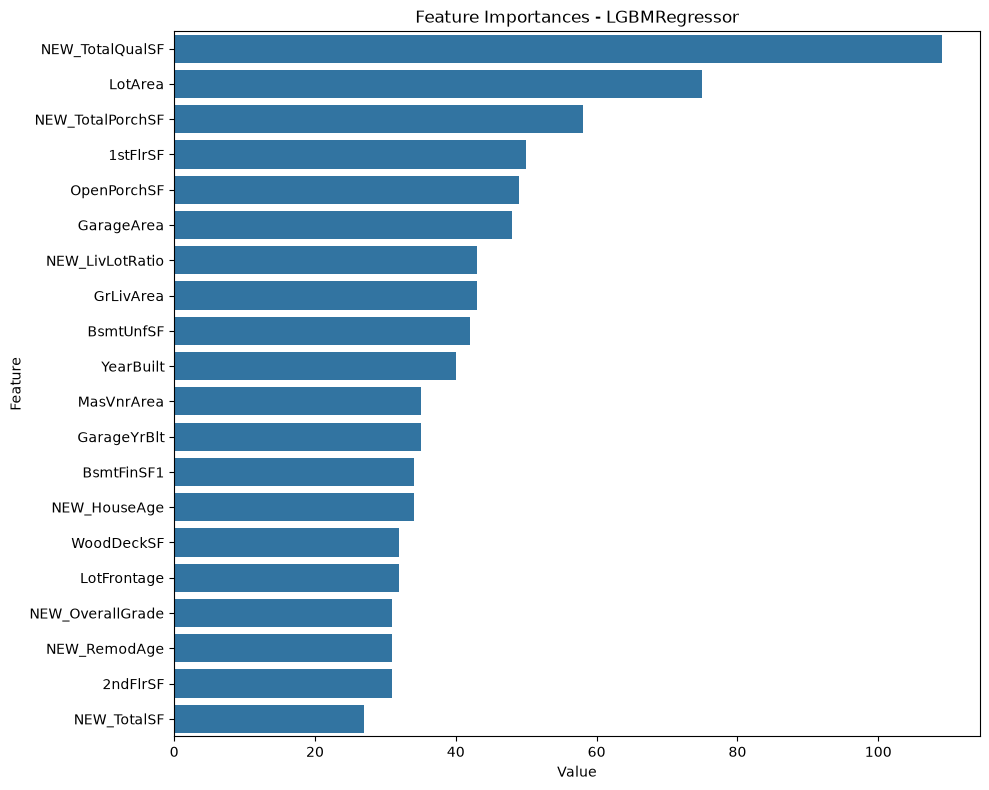

,Value,Feature
44,109,NEW_TotalQualSF
1,75,LotArea
43,58,NEW_TotalPorchSF
15,50,1stFlrSF
31,49,OpenPorchSF
29,48,GarageArea
51,43,NEW_LivLotRatio
18,43,GrLivArea
11,42,BsmtUnfSF
5,40,YearBuilt


In [30]:
def plot_importance(model, features, num=20, save=False):
    """
    Modelin bağımsız değişkenlere verdiği önemi yatay bar grafikte gösterir.
    Ağaç tabanlı modellerde feature_importances_ kullanılır.
    """
    if not hasattr(model, "feature_importances_"):
        print(f"{type(model).__name__} için feature_importances_ bulunamadı.")
        return

    feature_imp = pd.DataFrame({
        "Value": model.feature_importances_,
        "Feature": features.columns
    }).sort_values("Value", ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x="Value", y="Feature", data=feature_imp.iloc[:num])
    plt.title(f"Feature Importances - {type(model).__name__}")
    plt.tight_layout()
    plt.show()

    if save:
        plt.savefig("importances.png")

    return feature_imp


# Tüm train verisiyle final modeli fit et ve önem düzeylerini incele
final_model.fit(X, y_log)
importance_df = plot_importance(final_model, X, num=20)
importance_df.head(20)


Modelin en çok önem verdiği özellik **NEW_TotalQualSF** (alan × kalite) olmuştur. Bunu `LotArea`, `NEW_TotalPorchSF`, `1stFlrSF`, `GarageArea`, `GrLivArea`, `YearBuilt` ve `NEW_HouseAge` gibi alan / yaş değişkenleri izler. Ürettiğimiz `NEW_*` değişkenlerinden birçoğunun üst sıralarda yer alması, feature engineering adımının işe yaradığını gösterir.


### Bonus: Test verisinde boş olan SalePrice değişkenlerini tahminleyiniz ve Kaggle sayfasına submit etmeye uygun halde bir dataframe oluşturup sonucunuzu yükleyiniz.


In [31]:
# Test seti için log uzayında tahmin üret
test_log_pred = final_model.predict(X_test)

# Log'un tersini al (inverse): gerçek fiyat ölçeğine dön
test_price_pred = np.expm1(test_log_pred)

# Negatif fiyat oluşmasını engelle (nadir sayısal taşma güvenliği)
test_price_pred = np.clip(test_price_pred, a_min=0, a_max=None)

# Kaggle submission formatı: Id, SalePrice
submission_df = pd.DataFrame({
    "Id": test_ids.astype(int),
    "SalePrice": test_price_pred
})

# CSV olarak kaydet
submission_path = "datasets/house_prices/house_price_submission.csv"
submission_df.to_csv(submission_path, index=False)

print("Submission kaydedildi:", submission_path)
print(submission_df.head(10))
print("\nTahmin özeti:")
print(submission_df["SalePrice"].describe())


Submission kaydedildi: datasets/house_prices/house_price_submission.csv
        Id  SalePrice
1460  1461 112117.480
1461  1462 163804.987
1462  1463 176888.652
1463  1464 194851.664
1464  1465 184520.661
1465  1466 173291.483
1466  1467 189388.937
1467  1468 168238.994
1468  1469 184909.447
1469  1470 125277.840

Tahmin özeti:
count     1459.000
mean    177656.100
std      76103.502
min      46545.977
25%     127834.116
50%     156608.049
75%     209621.838
max     572802.889
Name: SalePrice, dtype: float64


**Yorum (Submission):** Test setindeki 1459 ev için fiyat tahmini üretilmiştir. Tahminlerin ortalaması yaklaşık **177.656** olup train'deki ortalama SalePrice (~180.921) ile uyumludur; bu, pipeline'ın makul çalıştığına işaret eder. Medyan ~156.608, min ~46.5k, max ~572.8k aralığı da gerçekçi görünmektedir. Dosya `house_price_submission.csv` olarak kaydedilmiştir; Kaggle'a yüklenebilir.
